In [1]:
from pathlib import Path

import jupyter_black
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from scipy.stats import permutation_test
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_curve
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from statsmodels.stats.multitest import fdrcorrection

from scipy.special import rel_entr
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use verbose pandas mode
pd.options.display.max_rows = 200

load_dotenv()
jupyter_black.load()

In [2]:
data_path = Path("/workspace/data/llmPredictions")
df_all = pd.read_csv(data_path / "merged_sdgs_predictions.csv")

# Confirm integrity
print(
    f"Loaded merged dataset: {df_all.shape[0]} rows, {df_all['DOI'].nunique()} unique DOIs"
)
print(
    df_all[
        [
            "DOI",
            "SDG",
            "Model",
            "model_label",
        ]
    ].head()
)

Loaded merged dataset: 93510 rows, 46572 unique DOIs
                             DOI   SDG Model   model_label
0             10.1093/sp/jxab007  SDG1  Qwen  Non-Relevant
1             10.1111/jomf.12987  SDG1  Qwen  Non-Relevant
2      10.1177/14733250231225170  SDG1  Qwen      Relevant
3     10.1016/j.eswa.2024.123680  SDG1  Qwen  Non-Relevant
4  10.1080/14616696.2020.1869283  SDG1  Qwen      Relevant


## Compute Agreement/Disagreement Splits

Setup
1.	We train a single TF-IDF model on all 46566 abstracts, ensuring shared vocabulary and comparable term weights across SDGs and label sets.  
2. 	We apply it to multiple subsets, including:  
    -	Per-model relevance judgments  
	-	Agreed and disagreed cases  
	-	Per-SDG comparisons  
	-	Cross-label comparisons (e.g., LLaMA Relevant vs. Non-Relevant). 

In [3]:
# Pivot dataset to compare model labels for the same abstract
df_pivot = df_all.pivot_table(
    index=["DOI", "Abstract", "SDG"],
    columns="Model",
    values="model_label",
    aggfunc="first",
).reset_index()

# Flatten column index if needed
df_pivot.columns.name = None
df_pivot.columns = [str(col) for col in df_pivot.columns]

# Drop rows where either model is missing a label
df_pivot.dropna(subset=["Llama", "Qwen"], inplace=True)

### Extract Disagreements & Subsets per SDG

Extract and analyze the abstracts where one model labeled "Relevant" while the other labeled "Non-Relevant."

In [4]:
df_disagreements = df_pivot[df_pivot["Llama"] != df_pivot["Qwen"]]
df_agreements = df_pivot[df_pivot["Llama"] == df_pivot["Qwen"]]

# Save global files
df_disagreements.to_csv(data_path / "model_disagreements.csv", index=False)
df_agreements.to_csv(data_path / "model_agreements.csv", index=False)

In [5]:
# Slice by SDG
SDGs = ["SDG1", "SDG3", "SDG7"]

dfs_disagree = {sdg: df_disagreements[df_disagreements["SDG"] == sdg] for sdg in SDGs}
dfs_agree = {sdg: df_agreements[df_agreements["SDG"] == sdg] for sdg in SDGs}


# Save per-SDG disagreement & agreement files
for sdg in SDGs:
    dfs_disagree[sdg].to_csv(data_path / f"model_disagreements_{sdg}.csv", index=False)
    dfs_agree[sdg].to_csv(data_path / f"model_agreements_{sdg}.csv", index=False)

In [6]:
# Extract abstracts per SDG (agreement and disagreement)
disagree_abstracts = {
    sdg: dfs_disagree[sdg]["Abstract"].dropna().unique().tolist() for sdg in SDGs
}

agree_abstracts = {
    sdg: dfs_agree[sdg]["Abstract"].dropna().unique().tolist() for sdg in SDGs
}

In [7]:
# Directional disagreement subsets (per SDG)
directional_mismatch = {}

for sdg in SDGs:
    df = dfs_disagree[sdg]

    key_LR_QN = f"{sdg}_Llama_Relevant_Qwen_NonRelevant"
    key_QR_LN = f"{sdg}_Qwen_Relevant_Llama_NonRelevant"

    directional_mismatch[key_LR_QN] = df[
        (df["Llama"] == "Relevant") & (df["Qwen"] == "Non-Relevant")
    ]

    directional_mismatch[key_QR_LN] = df[
        (df["Llama"] == "Non-Relevant") & (df["Qwen"] == "Relevant")
    ]

In [8]:
# Per-model, per-label subsets (Llama/Qwen x Relevant/Non-Relevant)
models = ["Llama", "Qwen"]
labels = ["Relevant", "Non-Relevant"]

llm_subsets = {
    (sdg, model, label): df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == model)
        & (df_all["model_label"] == label)
    ]
    for sdg in SDGs
    for model in models
    for label in labels
}

# Debug print (subset sizes)
for key, df in llm_subsets.items():
    print(f"{key}: {df.shape}")

('SDG1', 'Llama', 'Relevant'): (11369, 5)
('SDG1', 'Llama', 'Non-Relevant'): (3764, 5)
('SDG1', 'Qwen', 'Relevant'): (11495, 5)
('SDG1', 'Qwen', 'Non-Relevant'): (3638, 5)
('SDG3', 'Llama', 'Relevant'): (14132, 5)
('SDG3', 'Llama', 'Non-Relevant'): (1542, 5)
('SDG3', 'Qwen', 'Relevant'): (14233, 5)
('SDG3', 'Qwen', 'Non-Relevant'): (1441, 5)
('SDG7', 'Llama', 'Relevant'): (13062, 5)
('SDG7', 'Llama', 'Non-Relevant'): (2886, 5)
('SDG7', 'Qwen', 'Relevant'): (11433, 5)
('SDG7', 'Qwen', 'Non-Relevant'): (4515, 5)


### TF-IDF Modeling
Step 1: Fit a Unified TF-IDF Model on the Entire Corpus

In [9]:
# The unified corpus: all unique abstracts across SDG 1/3/7
corpus = df_all["Abstract"].dropna().unique().tolist()

# Fit ONE TF–IDF vectorizer on the whole collection
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,  # discard extremely rare terms
    max_df=0.95,  # discard extremely common terms
)

tfidf_full = tfidf_vectorizer.fit_transform(corpus)
vocab = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_full.shape}")
print(f"Vocabulary size: {len(vocab)}")

TF-IDF matrix shape: (46566, 30986)
Vocabulary size: 30986


Step 2: Transform Each Subset Using the Same Unified TF-IDF Model

In [10]:
# Build all TF–IDF subsets automatically
abstract_sets = {
    f"{sdg}_All": df_all[df_all["SDG"] == sdg]["Abstract"].dropna().unique().tolist()
    for sdg in SDGs
}

# 8.2: Agreement subsets (per SDG)
for sdg in SDGs:
    agrees = dfs_agree[sdg]
    abstract_sets[f"{sdg}_Agreed_Relevant"] = (
        agrees[agrees["Llama"] == "Relevant"]["Abstract"].dropna().unique().tolist()
    )
    abstract_sets[f"{sdg}_Agreed_NonRelevant"] = (
        agrees[agrees["Llama"] == "Non-Relevant"]["Abstract"].dropna().unique().tolist()
    )

# 8.3: LLM-specific filtering subsets (Llama/Qwen × Relevant/Non-Relevant)
for (sdg, model, label), df in llm_subsets.items():
    key = f"{sdg}_{model}_{label.replace('-', '')}"
    abstract_sets[key] = df["Abstract"].dropna().unique().tolist()

# 8.4: Model union sets (Llama ∪ Qwen per label)
for sdg in SDGs:
    for label in ["Relevant", "Non-Relevant"]:
        llama_set = llm_subsets[(sdg, "Llama", label)]["Abstract"].dropna().unique()
        qwen_set = llm_subsets[(sdg, "Qwen", label)]["Abstract"].dropna().unique()
        union_key = f"{sdg}_Llama_vs_Qwen_{label.replace('-', '')}"
        abstract_sets[union_key] = list(set(llama_set).union(set(qwen_set)))

# 8.5: Disagreement abstracts (per SDG)
for sdg in SDGs:
    abstract_sets[f"{sdg}_Disagreements"] = (
        dfs_disagree[sdg]["Abstract"].dropna().unique().tolist()
    )

# 8.6: Directional disagreement subsets (LR-QN vs. QR-LN)
for key, df in directional_mismatch.items():
    abstract_sets[key] = df["Abstract"].dropna().unique().tolist()

print(f"Total TF-IDF subsets: {len(abstract_sets)}")

Total TF-IDF subsets: 36


In [11]:
# Transform each subset using the unified TF–IDF vectorizer
tfidf_matrices = {}

for name, texts in abstract_sets.items():
    if len(texts) == 0:
        print(f"Skipping {name}: empty subset.")
        continue

    tfidf_matrices[name] = tfidf_vectorizer.transform(texts)
    print(f"TF-IDF: {name:40s}  ({len(texts)} abstracts)")

print("TF-IDF transformation complete.")

TF-IDF: SDG1_All                                  (15132 abstracts)
TF-IDF: SDG3_All                                  (15668 abstracts)
TF-IDF: SDG7_All                                  (15948 abstracts)
TF-IDF: SDG1_Agreed_Relevant                      (10050 abstracts)
TF-IDF: SDG1_Agreed_NonRelevant                   (2320 abstracts)
TF-IDF: SDG3_Agreed_Relevant                      (13364 abstracts)
TF-IDF: SDG3_Agreed_NonRelevant                   (679 abstracts)
TF-IDF: SDG7_Agreed_Relevant                      (10598 abstracts)
TF-IDF: SDG7_Agreed_NonRelevant                   (2051 abstracts)
TF-IDF: SDG1_Llama_Relevant                       (11368 abstracts)
TF-IDF: SDG1_Llama_NonRelevant                    (3764 abstracts)
TF-IDF: SDG1_Qwen_Relevant                        (11494 abstracts)
TF-IDF: SDG1_Qwen_NonRelevant                     (3638 abstracts)
TF-IDF: SDG3_Llama_Relevant                       (14126 abstracts)
TF-IDF: SDG3_Llama_NonRelevant                    (154

In [12]:
# Save the TF–IDF vocabulary for later analysis
vocab_path = data_path / "tfidf_feature_names.pkl"
pd.to_pickle(vocab, vocab_path)
print(f"Vocabulary saved to {vocab_path}")

Vocabulary saved to /workspace/data/llmPredictions/tfidf_feature_names.pkl


Step 3: Compute TF-IDF Differences Across Groups

In [13]:
# Compute TF–IDF mean differences between any two groups


def compute_tfidf_difference(tfidf_matrices, vocab, group1, group2):
    """
    Compute the difference in mean TF–IDF scores between two groups.

    Parameters
    ----------
    tfidf_matrices : dict
        Mapping from group name → sparse TF–IDF matrix.
    vocab : array-like
        List/array of feature names from the TF–IDF vectorizer.
    group1 : str
        Baseline group name.
    group2 : str
        Comparison group name.

    Returns
    -------
    pd.DataFrame
        DataFrame with Term and TFIDF_Diff columns,
        sorted so positive values indicate higher scores in group2.
    """

    if group1 not in tfidf_matrices or group2 not in tfidf_matrices:
        missing = [g for g in [group1, group2] if g not in tfidf_matrices]
        print(f"Missing TF–IDF matrices for: {missing}")
        return pd.DataFrame()

    # Mean TF–IDF per term for each group
    tfidf1 = np.asarray(tfidf_matrices[group1].mean(axis=0)).ravel()
    tfidf2 = np.asarray(tfidf_matrices[group2].mean(axis=0)).ravel()

    # Difference (positive = stronger in group2)
    diff = tfidf2 - tfidf1

    df = pd.DataFrame({"Term": vocab, "TFIDF_Diff": diff}).sort_values(
        "TFIDF_Diff", ascending=False
    )

    return df

Compute differentiating terms between the two groups of abstracts (i.e., relevant vs. non-relevant) for each SDG.

In [14]:
# Define the comparison tasks

# 1. Llama vs Qwen (per SDG × label)
llama_vs_qwen = [
    (f"{sdg}_Llama_Relevant", f"{sdg}_Qwen_Relevant", f"{sdg}_LxQ_Relevant")
    for sdg in SDGs
] + [
    (f"{sdg}_Llama_NonRelevant", f"{sdg}_Qwen_NonRelevant", f"{sdg}_LxQ_NonRelevant")
    for sdg in SDGs
]

# 2. Relevant vs Non-Relevant (per LLM × SDG)
rel_vs_non = [
    (
        f"{sdg}_{model}_Relevant",
        f"{sdg}_{model}_NonRelevant",
        f"{sdg}_{model}_Rel_vs_NonRel",
    )
    for sdg in SDGs
    for model in models
]

# 3. Disagreement vs Agreed Relevant (per SDG)
disagree_vs_agreed = [
    (f"{sdg}_Disagreements", f"{sdg}_Agreed_Relevant", f"{sdg}_Disagree_vs_AgreedRel")
    for sdg in SDGs
]

# Combine all comparison tasks into one list
comparison_tasks = llama_vs_qwen + rel_vs_non + disagree_vs_agreed

# Run TF–IDF comparisons
tfidf_differences = {}

for g1, g2, name in comparison_tasks:

    df_diff = compute_tfidf_difference(tfidf_matrices, vocab, g1, g2)
    tfidf_differences[name] = df_diff

    print(f"Computed TF–IDF diff: {name}  ({g1} → {g2})")

Computed TF–IDF diff: SDG1_LxQ_Relevant  (SDG1_Llama_Relevant → SDG1_Qwen_Relevant)
Computed TF–IDF diff: SDG3_LxQ_Relevant  (SDG3_Llama_Relevant → SDG3_Qwen_Relevant)
Computed TF–IDF diff: SDG7_LxQ_Relevant  (SDG7_Llama_Relevant → SDG7_Qwen_Relevant)
Computed TF–IDF diff: SDG1_LxQ_NonRelevant  (SDG1_Llama_NonRelevant → SDG1_Qwen_NonRelevant)
Computed TF–IDF diff: SDG3_LxQ_NonRelevant  (SDG3_Llama_NonRelevant → SDG3_Qwen_NonRelevant)


Computed TF–IDF diff: SDG7_LxQ_NonRelevant  (SDG7_Llama_NonRelevant → SDG7_Qwen_NonRelevant)
Computed TF–IDF diff: SDG1_Llama_Rel_vs_NonRel  (SDG1_Llama_Relevant → SDG1_Llama_NonRelevant)
Computed TF–IDF diff: SDG1_Qwen_Rel_vs_NonRel  (SDG1_Qwen_Relevant → SDG1_Qwen_NonRelevant)
Computed TF–IDF diff: SDG3_Llama_Rel_vs_NonRel  (SDG3_Llama_Relevant → SDG3_Llama_NonRelevant)
Computed TF–IDF diff: SDG3_Qwen_Rel_vs_NonRel  (SDG3_Qwen_Relevant → SDG3_Qwen_NonRelevant)
Computed TF–IDF diff: SDG7_Llama_Rel_vs_NonRel  (SDG7_Llama_Relevant → SDG7_Llama_NonRelevant)
Computed TF–IDF diff: SDG7_Qwen_Rel_vs_NonRel  (SDG7_Qwen_Relevant → SDG7_Qwen_NonRelevant)
Computed TF–IDF diff: SDG1_Disagree_vs_AgreedRel  (SDG1_Disagreements → SDG1_Agreed_Relevant)
Computed TF–IDF diff: SDG3_Disagree_vs_AgreedRel  (SDG3_Disagreements → SDG3_Agreed_Relevant)
Computed TF–IDF diff: SDG7_Disagree_vs_AgreedRel  (SDG7_Disagreements → SDG7_Agreed_Relevant)


In [15]:
# Print the top differentiating terms (head 10) per comparison
for name, df_diff in tfidf_differences.items():
    print("\n", "=" * 70)
    print(f"Top Differentiating Terms: {name}")
    print(df_diff.head(10))


Top Differentiating Terms: SDG1_LxQ_Relevant
            Term  TFIDF_Diff
13436     health    0.002186
5383        care    0.001763
15247  insurance    0.001606
7559    coverage    0.001211
7566       covid    0.001194
17663   medicaid    0.001160
504           19    0.001083
20345     opioid    0.001047
6104          ci    0.000991
1744          95    0.000905

Top Differentiating Terms: SDG3_LxQ_Relevant
            Term  TFIDF_Diff
21087   patients    0.001374
1744          95    0.000450
18556     months    0.000446
6104          ci    0.000442
27921       tavr    0.000417
19581  nivolumab    0.000387
19913      nsclc    0.000376
14470    imaging    0.000371
7406    coronary    0.000364
30290         vs    0.000363

Top Differentiating Terms: SDG7_LxQ_Relevant
              Term  TFIDF_Diff
10457       energy    0.004101
22420        power    0.002599
30589         wind    0.001655
24363    renewable    0.001589
12323         fuel    0.001533
10072  electricity    0.001391
7473   

### Key Observations from TF–IDF Term Differences

#### SDG 1 (No Poverty)
- LLaMA-Relevant terms concentrate on social protection and health-related service contexts (e.g., *health*, *care*, *insurance*, *coverage*, *covid*), indicating an applied or service-delivery framing.  
- Qwen-Non-Relevant terms highlight structural or macroeconomic factors (e.g., *inequality*, *income*, *tax*, *wealth*, *gini*).  
- Disagreement-associated terms include *food*, *poverty*, *insecurity*, *households*, *children*, which fall into indirect domains of poverty research where relevance boundaries are less uniform.

#### SDG 3 (Good Health and Well-Being)
- LLaMA-Relevant terms include clinical markers and trial contexts (e.g., *patients*, *pfs*, *survival*, *nivolumab*, *nsclc*).  
- Qwen-Non-Relevant terms emphasize cellular and molecular biology (e.g., *tumor*, *cell*, *chromatin*, *signaling*).  
- Disagreement terms cluster around pandemic-related vocabulary (*covid*, *infection*, *sars*, *vaccine*), indicating uncertainty about whether contextual public-health topics count as contributions.

#### SDG 7 (Affordable and Clean Energy)
- LLaMA-Relevant terms cover energy-system and renewable-generation contexts (e.g., *energy*, *solar*, *wind*, *grid*, *electricity*).  
- Qwen-Non-Relevant terms emphasize materials-science and electrochemical vocabulary (e.g., *lithium*, *electrolyte*, *anode*, *ion*, *battery*).  
- Disagreement terms again reflect renewable-energy and storage-related terminology, marking variation in how technical research in materials or chemistry is mapped to SDG 7’s policy-oriented scope.


#### Interpretation
With all SDGs, the differentiating terms align with recognizable thematic boundaries inside each goal area.  
The terms associated with disagreement consistently fall at these boundary regions—areas where abstracts reference related phenomena or enabling technologies that may or may not be construed as direct contributions.  
This pattern indicates that model divergence arises at the conceptual edges of each SDG rather than from isolated or arbitrary lexical differences.

In [16]:
# Permutation test on top-N TF–IDF-differentiating terms
def run_permutation_test_on_top_terms(
    tfidf_matrices,
    vocab,
    group1,
    group2,
    top_n=200,
    n_resamples=9999,
    alpha=0.05,
):
    """
    Run permutation tests on the top-N TF–IDF-differentiating terms.

    Parameters
    ----------
    tfidf_matrices : dict[str, sparse matrix]
        Precomputed TF–IDF matrices for each group.
    vocab : array-like
        Vocabulary from the unified TF–IDF vectorizer.
    group1 : str
        Baseline group.
    group2 : str
        Comparison group.
    top_n : int
        Number of highest-absolute-difference terms to test.
    n_resamples : int
        Number of permutations.
    alpha : float
        Significance threshold for FDR correction.

    Returns
    -------
    pd.DataFrame
        Columns: Term, TFIDF_Diff, raw_p_value, fdr_p_value
    """

    if group1 not in tfidf_matrices or group2 not in tfidf_matrices:
        raise ValueError(f"Missing TF–IDF matrices for: {group1} or {group2}")

    # Convert sparse → dense once
    X1 = tfidf_matrices[group1].toarray()
    X2 = tfidf_matrices[group2].toarray()

    # Mean TF–IDF difference vector
    diff = np.mean(X2, axis=0) - np.mean(X1, axis=0)

    # Select top-N absolute differences
    top_idx = np.argsort(np.abs(diff))[::-1][:top_n]

    results = []
    for idx in top_idx:
        term = vocab[idx]
        x1 = X1[:, idx]
        x2 = X2[:, idx]

        # Two-sided independent permutation test
        test_res = permutation_test(
            data=(x1, x2),
            statistic=lambda a, b: np.mean(b) - np.mean(a),
            permutation_type="independent",
            n_resamples=n_resamples,
            alternative="two-sided",
            vectorized=False,
        )
        results.append((term, diff[idx], test_res.pvalue))

    df = pd.DataFrame(results, columns=["Term", "TFIDF_Diff", "raw_p_value"])
    df["fdr_p_value"] = fdrcorrection(df["raw_p_value"], alpha=alpha)[1]

    return df.sort_values("fdr_p_value").reset_index(drop=True)

In [18]:
# Directional disagreement comparisons (per SDG)
mismatch_pairs = {
    "SDG1_mismatch": (
        "SDG1_Llama_Relevant_Qwen_NonRelevant",
        "SDG1_Qwen_Relevant_Llama_NonRelevant",
    ),
    "SDG3_mismatch": (
        "SDG3_Llama_Relevant_Qwen_NonRelevant",
        "SDG3_Qwen_Relevant_Llama_NonRelevant",
    ),
    "SDG7_mismatch": (
        "SDG7_Llama_Relevant_Qwen_NonRelevant",
        "SDG7_Qwen_Relevant_Llama_NonRelevant",
    ),
}

permutation_results = {}

for name, (g1, g2) in mismatch_pairs.items():

    if g1 not in tfidf_matrices or g2 not in tfidf_matrices:
        print(f"Skipping {name}: missing TF–IDF matrix.")
        continue

    print("\n" + "=" * 70)
    print(f"Permutation Test for {name}")
    print(f"  Baseline:   {g1}")
    print(f"  Comparison: {g2}")

    df_perm = run_permutation_test_on_top_terms(
        tfidf_matrices=tfidf_matrices,
        vocab=vocab,
        group1=g1,
        group2=g2,
        top_n=200,
        n_resamples=9999,
        alpha=0.05,
    )

    permutation_results[name] = df_perm

    print("\nTop 40 terms:")
    print(df_perm.head(40))


Permutation Test for SDG1_mismatch
  Baseline:   SDG1_Llama_Relevant_Qwen_NonRelevant
  Comparison: SDG1_Qwen_Relevant_Llama_NonRelevant

Top 40 terms:
              Term  TFIDF_Diff  raw_p_value  fdr_p_value
0       inequality   -0.020004       0.0002     0.000635
1           health    0.018527       0.0002     0.000635
2             care    0.014424       0.0002     0.000635
3        insurance    0.012886       0.0002     0.000635
4           wealth   -0.011671       0.0002     0.000635
5            covid    0.010227       0.0002     0.000635
6         coverage    0.009975       0.0002     0.000635
7         medicaid    0.009486       0.0002     0.000635
8               19    0.009237       0.0002     0.000635
9           opioid    0.008282       0.0002     0.000635
10             tax   -0.008175       0.0002     0.000635
11              ci    0.007965       0.0002     0.000635
12              95    0.007280       0.0002     0.000635
13          states    0.007386       0.0002     0

##  Kullback–Leibler (KL) divergence 

In [19]:
# KL Divergence
def compute_kl_divergence(tfidf_matrices, group1, group2, epsilon=1e-9):
    """
    Compute KL divergence D_KL(P || Q) between two TF–IDF
    mean-term distributions.

    Parameters
    ----------
    tfidf_matrices : dict
        group_name → sparse TF–IDF matrix
    group1 : str
        Baseline distribution (P)
    group2 : str
        Comparison distribution (Q)
    epsilon : float
        Smoothing constant

    Returns
    -------
    float
        KL divergence D_KL(P || Q)
    """

    if group1 not in tfidf_matrices or group2 not in tfidf_matrices:
        raise ValueError(f"Missing TF–IDF matrix for: {group1} or {group2}")

    # Mean TF–IDF vectors
    tfidf1 = np.asarray(tfidf_matrices[group1].mean(axis=0)).ravel()
    tfidf2 = np.asarray(tfidf_matrices[group2].mean(axis=0)).ravel()

    # Convert to probability distributions
    p = (tfidf1 + epsilon) / (tfidf1 + epsilon).sum()
    q = (tfidf2 + epsilon) / (tfidf2 + epsilon).sum()

    # KL divergence D_KL(P || Q)
    return float(np.sum(rel_entr(p, q)))

In [22]:
kl_results = {}

for sdg, (g1, g2) in mismatch_pairs.items():
    kl = compute_kl_divergence(tfidf_matrices, g1, g2)
    kl_results[sdg] = kl
    print(f"KL Divergence ({sdg}): {kl:.4f}")

KL Divergence (SDG1_mismatch): 1.0487
KL Divergence (SDG3_mismatch): 1.5991
KL Divergence (SDG7_mismatch): 1.2568


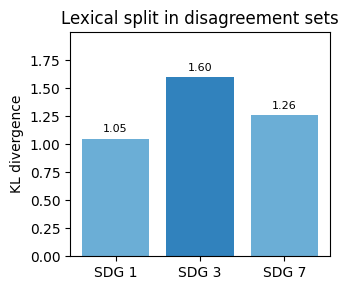

In [24]:
# sdgs = list(kl_results.keys())
sdgs = ["SDG 1", "SDG 3", "SDG 7"]
klds = list(kl_results.values())

plt.figure(figsize=(3.5, 3))
bars = plt.bar(sdgs, klds, color=["#6baed6", "#3182bd", "#6baed6"])

for b, v in zip(bars, klds):
    plt.text(
        b.get_x() + b.get_width() / 2,
        v + 0.04,
        f"{v:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.ylabel("KL divergence")
plt.title("Lexical split in disagreement sets")
plt.ylim(0, max(klds) * 1.25)
plt.tight_layout()
plt.show()

## Evaluate How Filtering Bias Affects Retrieval

Goal: Quantify how differences in filtering decisions between Llama and Qwen affect which documents are retrieved for SDG queries.

### Representative Query Retrieval Results

In [33]:
def get_top_terms(matrix, vocab, top_n=20):
    avg_scores = np.asarray(matrix.mean(axis=0)).flatten()
    top_indices = avg_scores.argsort()[::-1][:top_n]
    terms = vocab[top_indices]
    scores = avg_scores[top_indices]
    return pd.DataFrame({"term": terms, "score": scores})


# Extract top terms from each SDG group
top_terms_sdg1 = get_top_terms(tfidf_matrices["SDG1_All"], vocab)
top_terms_sdg3 = get_top_terms(tfidf_matrices["SDG3_All"], vocab)
top_terms_sdg7 = get_top_terms(tfidf_matrices["SDG7_All"], vocab)

# Print as TF-IDF-based lexical queries
print("SDG1 Query:", " ".join(top_terms_sdg1["term"]))
print("SDG3 Query:", " ".join(top_terms_sdg3["term"]))
print("SDG7 Query:", " ".join(top_terms_sdg7["term"]))

SDG1 Query: health income social poverty food inequality care policy study economic data children women insurance access level public financial countries research
SDG3 Query: patients cancer covid 19 disease cells cov cell sars 95 ci risk tumor treatment clinical associated health infection immune response
SDG7 Query: energy power high performance solar efficiency based li carbon model wind ion water hydrogen proposed materials lithium capacity batteries battery


In [34]:
# Define lexical queries for TF-IDF retrieval based on top terms
queries = {
    "SDG1": "health income social poverty food inequality care policy",
    "SDG3": "patients cancer covid disease tumor treatment clinical infection",
    "SDG7": "energy power solar efficiency carbon model hydrogen lithium",
}

In [35]:
# Transform the cleaned query strings into TF-IDF vectors
query_vectors = {
    sdg: tfidf_vectorizer.transform([query]) for sdg, query in queries.items()
}

In [37]:
# Helper to print examples
def print_top_disagreement_examples(df, ranked_dois, model_name, sdg_label, top_n=10):
    print(
        f"\nTop {top_n} abstracts in SDG{sdg_label} disagreement set ranked by {model_name}:"
    )
    top_df = df[df["DOI"].isin(ranked_dois[:top_n])]
    for i, row in top_df.iterrows():
        print(f"\n{i+1}. DOI: {row['DOI']}")
        print(f"   Abstract: {row['Abstract'][:300]}...")
        print(
            f"   LLaMA: {row.get('llama_result', 'N/A')}, Qwen: {row.get('qwen_result', 'N/A')}"
        )


# Parameters
k = 20
disagreement_query_results = {}

for sdg in ["SDG1", "SDG3", "SDG7"]:
    # LLaMA Relevant, Qwen Non-Relevant
    df_llama_pos = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Llama")
        & (df_all["model_label"] == "Relevant")
    ]
    df_qwen_neg = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Qwen")
        & (df_all["model_label"] == "Non-Relevant")
    ]
    llama_disagree = pd.merge(
        df_llama_pos, df_qwen_neg, on="DOI", suffixes=("_llama", "_qwen")
    )

    # Qwen Relevant, LLaMA Non-Relevant
    df_qwen_pos = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Qwen")
        & (df_all["model_label"] == "Relevant")
    ]
    df_llama_neg = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Llama")
        & (df_all["model_label"] == "Non-Relevant")
    ]
    qwen_disagree = pd.merge(
        df_qwen_pos, df_llama_neg, on="DOI", suffixes=("_qwen", "_llama")
    )

    # Combine and label
    llama_disagree["llama_result"] = "Relevant"
    llama_disagree["qwen_result"] = "Non-Relevant"
    llama_disagree["Abstract"] = llama_disagree["Abstract_llama"]

    qwen_disagree["llama_result"] = "Non-Relevant"
    qwen_disagree["qwen_result"] = "Relevant"
    qwen_disagree["Abstract"] = qwen_disagree["Abstract_qwen"]

    df_disagree = pd.concat(
        [llama_disagree, qwen_disagree], ignore_index=True
    ).drop_duplicates(subset="DOI")

    if df_disagree.empty:
        disagreement_query_results[sdg] = {
            "LLaMA Top-k Count": 0,
            "Qwen Top-k Count": 0,
            "Both Models": 0,
            "Only LLaMA": 0,
            "Only Qwen": 0,
        }
        continue

    # TF-IDF vectorization
    abstracts = df_disagree["Abstract"].fillna("").tolist()
    tfidf_matrix = tfidf_vectorizer.transform(abstracts)  # Using full corpus vectorizer
    query_vector = query_vectors[sdg]  # Precomputed representative query

    # Score all disagreement documents
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    topk_indices = np.argsort(similarity_scores)[::-1][:k]
    topk_dois = df_disagree.iloc[topk_indices]["DOI"].tolist()

    # Label counts
    llama_relevant = set(df_disagree[df_disagree["llama_result"] == "Relevant"]["DOI"])
    qwen_relevant = set(df_disagree[df_disagree["qwen_result"] == "Relevant"]["DOI"])
    topk_set = set(topk_dois)

    llama_topk = topk_set & llama_relevant
    qwen_topk = topk_set & qwen_relevant

    disagreement_query_results[sdg] = {
        "LLaMA Top-k Count": len(llama_topk),
        "Qwen Top-k Count": len(qwen_topk),
        "Both Models": len(llama_topk & qwen_topk),
        "Only LLaMA": len(llama_topk - qwen_topk),
        "Only Qwen": len(qwen_topk - llama_topk),
    }

    # Show examples
    print_top_disagreement_examples(df_disagree, list(llama_topk), "LLaMA", sdg)
    print_top_disagreement_examples(df_disagree, list(qwen_topk), "Qwen", sdg)

# Final results
print("\nDisagreement Representative Query Retrieval Results:")
print(disagreement_query_results)


Top 10 abstracts in SDGSDG1 disagreement set ranked by LLaMA:

15. DOI: 10.1377/hlthaff.2020.01566
   Abstract: A high-performing health care system strives to achieve universal access, affordability, high-quality care, and equity, aiming to reduce inequality in outcomes and access. Using data from the 2020 Commonwealth Fund International Health Policy Survey, we report on health status, socioeconomic risk fa...
   LLaMA: Relevant, Qwen: Non-Relevant

172. DOI: 10.1111/ssqu.13269
   Abstract: Objectives: This study aims to contribute to our understanding of the relationship between income inequality, perceptions of income inequality, and support for redistribution. In particular, it asks whether income inequality affects support for redistribution by influencing perceptions of inequality...
   LLaMA: Relevant, Qwen: Non-Relevant

338. DOI: 10.1111/jmwh.13510
   Abstract: Introduction: A qualitative picture of the health care experiences prior to pregnancy can inform patient-centered s

### Centroid Retrieval Results

In [32]:
# Helper to print example documents
def print_top_disagreement_examples(df, ranked_dois, model_name, sdg_label, top_n=10):
    print(
        f"\nTop {top_n} abstracts in SDG{sdg_label} disagreement set ranked by {model_name}:"
    )
    top_df = df[df["DOI"].isin(ranked_dois[:top_n])]
    for i, row in top_df.iterrows():
        print(f"\n{i+1}. DOI: {row['DOI']}")
        print(f"   Abstract: {row['Abstract'][:300]}...")
        print(
            f"   LLaMA: {row.get('llama_result', 'N/A')}, Qwen: {row.get('qwen_result', 'N/A')}"
        )


# Parameters
k = 20
disagreement_centroid_results = {}

for sdg in ["SDG1", "SDG3", "SDG7"]:
    # Identify disagreement subsets
    df_llama_pos = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Llama")
        & (df_all["model_label"] == "Relevant")
    ]
    df_qwen_neg = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Qwen")
        & (df_all["model_label"] == "Non-Relevant")
    ]
    llama_disagree = pd.merge(
        df_llama_pos, df_qwen_neg, on="DOI", suffixes=("_llama", "_qwen")
    )

    df_qwen_pos = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Qwen")
        & (df_all["model_label"] == "Relevant")
    ]
    df_llama_neg = df_all[
        (df_all["SDG"] == sdg)
        & (df_all["Model"] == "Llama")
        & (df_all["model_label"] == "Non-Relevant")
    ]
    qwen_disagree = pd.merge(
        df_qwen_pos, df_llama_neg, on="DOI", suffixes=("_qwen", "_llama")
    )

    # Combine disagreement sets and label
    llama_disagree["llama_result"] = "Relevant"
    llama_disagree["qwen_result"] = "Non-Relevant"
    llama_disagree["Abstract"] = llama_disagree["Abstract_llama"]

    qwen_disagree["llama_result"] = "Non-Relevant"
    qwen_disagree["qwen_result"] = "Relevant"
    qwen_disagree["Abstract"] = qwen_disagree["Abstract_qwen"]

    df_disagree = pd.concat(
        [llama_disagree, qwen_disagree], ignore_index=True
    ).drop_duplicates(subset="DOI")
    if df_disagree.empty:
        disagreement_centroid_results[sdg] = {
            "LLaMA Top-k Count": 0,
            "Qwen Top-k Count": 0,
            "Both Models": 0,
            "Only LLaMA": 0,
            "Only Qwen": 0,
        }
        continue

    # Vectorize using full corpus vectorizer
    abstracts = df_disagree["Abstract"].fillna("").tolist()
    tfidf_matrix = tfidf_vectorizer.transform(abstracts)

    # Compute shared centroid over all disagreement abstracts
    centroid_vector = tfidf_matrix.mean(axis=0).A1

    # Score all abstracts in shared pool using same centroid
    similarity_scores = cosine_similarity(
        centroid_vector.reshape(1, -1), tfidf_matrix
    ).flatten()

    # Get ranked document DOIs
    topk_indices = np.argsort(similarity_scores)[::-1][:k]
    topk_dois = df_disagree.iloc[topk_indices]["DOI"].tolist()

    # Ground-truth labels
    llama_relevant = set(df_disagree[df_disagree["llama_result"] == "Relevant"]["DOI"])
    qwen_relevant = set(df_disagree[df_disagree["qwen_result"] == "Relevant"]["DOI"])
    topk_set = set(topk_dois)

    llama_topk = topk_set & llama_relevant
    qwen_topk = topk_set & qwen_relevant

    disagreement_centroid_results[sdg] = {
        "LLaMA Top-k Count": len(llama_topk),
        "Qwen Top-k Count": len(qwen_topk),
        "Both Models": len(llama_topk & qwen_topk),
        "Only LLaMA": len(llama_topk - qwen_topk),
        "Only Qwen": len(qwen_topk - llama_topk),
    }

    print_top_disagreement_examples(df_disagree, list(llama_topk), "LLaMA", sdg)
    print_top_disagreement_examples(df_disagree, list(qwen_topk), "Qwen", sdg)

print("\nDisagreement Centroid Retrieval Results (Shared Pool):")
print(disagreement_centroid_results)


Top 10 abstracts in SDGSDG1 disagreement set ranked by LLaMA:

15. DOI: 10.1377/hlthaff.2020.01566
   Abstract: A high-performing health care system strives to achieve universal access, affordability, high-quality care, and equity, aiming to reduce inequality in outcomes and access. Using data from the 2020 Commonwealth Fund International Health Policy Survey, we report on health status, socioeconomic risk fa...
   LLaMA: Relevant, Qwen: Non-Relevant

267. DOI: 10.1001/jamahealthforum.2023.4593
   Abstract: Importance: Many states have moved from models that carve out to those that carve in or integrate behavioral health in their Medicaid managed care organizations (MCOs), but little evidence exists about the effect of this change. Objective: To assess the association of the transition to integrated ma...
   LLaMA: Relevant, Qwen: Non-Relevant

347. DOI: 10.1177/10783903231197655
   Abstract: BACKGROUND: This analysis aimed to examine the factors predictive of service utilization amon

## Predicting Disagreement

In [40]:
def compute_auc_from_disagreements(df_llama, df_qwen, sdg_label):
    df_llama = df_llama.copy()
    df_qwen = df_qwen.copy()

    df_llama["label"] = 0  # LLaMA = 0
    df_qwen["label"] = 1  # Qwen = 1

    df_combined = pd.concat([df_llama, df_qwen], ignore_index=True)

    # Extract labels
    labels = df_combined["label"].tolist()

    # TF-IDF vectors for these abstracts
    X = tfidf_vectorizer.transform(df_combined["Abstract"].fillna("").tolist())

    clf = LogisticRegression(max_iter=1000)
    auc_scores = cross_val_score(clf, X, labels, cv=5, scoring="roc_auc")

    print(f"SDG{sdg_label} AUC: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

In [41]:
compute_auc_from_disagreements(
    directional_mismatch["SDG1_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG1_Qwen_Relevant_Llama_NonRelevant"],
    sdg_label=1,
)

compute_auc_from_disagreements(
    directional_mismatch["SDG3_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG3_Qwen_Relevant_Llama_NonRelevant"],
    sdg_label=3,
)

compute_auc_from_disagreements(
    directional_mismatch["SDG7_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG7_Qwen_Relevant_Llama_NonRelevant"],
    sdg_label=7,
)

SDG1 AUC: 0.739 ± 0.018
SDG3 AUC: 0.753 ± 0.034
SDG7 AUC: 0.703 ± 0.084


In [42]:
def plot_roc(df_llama, df_qwen, sdg_label, vectorizer):
    # Prepare data
    df_llama = df_llama.copy()
    df_qwen = df_qwen.copy()
    df_llama["label"] = 0  # LLaMA = 0
    df_qwen["label"] = 1  # Qwen = 1

    df_combined = pd.concat([df_llama, df_qwen], ignore_index=True)

    X = vectorizer.transform(df_combined["Abstract"].fillna(""))
    y = df_combined["label"].values

    # Predict probabilities using cross-validation
    clf = LogisticRegression(max_iter=1000)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_scores = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]

    # ROC & AUC
    fpr, tpr, _ = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"SDG {sdg_label} (AUC = {roc_auc:.3f})")

In [43]:
# Build unified training set from all mismatch cases
df_all_mismatch = pd.concat(
    [
        directional_mismatch["SDG1_Llama_Relevant_Qwen_NonRelevant"],
        directional_mismatch["SDG1_Qwen_Relevant_Llama_NonRelevant"],
        directional_mismatch["SDG3_Llama_Relevant_Qwen_NonRelevant"],
        directional_mismatch["SDG3_Qwen_Relevant_Llama_NonRelevant"],
        directional_mismatch["SDG7_Llama_Relevant_Qwen_NonRelevant"],
        directional_mismatch["SDG7_Qwen_Relevant_Llama_NonRelevant"],
    ],
    ignore_index=True,
)

vectorizer = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.95)
vectorizer.fit(df_all_mismatch["Abstract"].fillna(""))

TfidfVectorizer(max_df=0.95, min_df=5, stop_words='english')

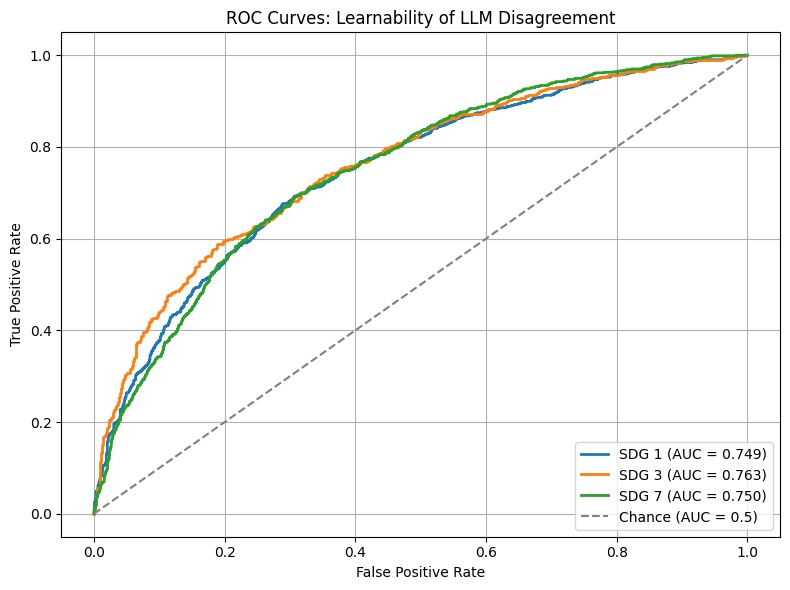

In [44]:
plt.figure(figsize=(8, 6))

plot_roc(
    directional_mismatch["SDG1_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG1_Qwen_Relevant_Llama_NonRelevant"],
    1,
    vectorizer,
)

plot_roc(
    directional_mismatch["SDG3_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG3_Qwen_Relevant_Llama_NonRelevant"],
    3,
    vectorizer,
)

plot_roc(
    directional_mismatch["SDG7_Llama_Relevant_Qwen_NonRelevant"],
    directional_mismatch["SDG7_Qwen_Relevant_Llama_NonRelevant"],
    7,
    vectorizer,
)

# Final touches
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Learnability of LLM Disagreement")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()